All libraries imported successfully!
Dataset shape : (47720, 10)
Columns       : ['Year', 'Show_name', 'Potential_Gross', 'Difference', 'Average_ticket', 'Seats_Sold', 'Seats_in_theater', 'Previews', '%cap', 'diff_cap']
Rows after cleaning : 47569
Feature matrix shape : (47569, 7)
Target vector shape  : (47569, 1)

Sequences created!
  X shape : (35288, 13, 7)
    → 35288 samples
    → 13 time steps (weeks)
    → 7 features per week
  y shape : (35288, 1)

Training samples : 28230
Testing samples  : 7058


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 11, 128)        │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 2, 64)          │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,699 (229.29 KB)

 Trainable params: 58,699 (229.29 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...

Epoch 1/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0015 - mae: 0.0256 - val_loss: 9.8381e-04 - val_mae: 0.0215
Epoch 2/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 9.8476e-04 - mae: 0.0216 - val_loss: 8.5490e-04 - val_mae: 0.0197
Epoch 3/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 9.3297e-04 - mae: 0.0210 - val_loss: 7.8007e-04 - val_mae: 0.0197
Epoch 4/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 8.7363e-04 - mae: 0.0203 - val_loss: 8.5076e-04 - val_mae: 0.0194
Epoch 5/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 8.7933e-04 - mae: 0.0203 - val_loss: 9.9937e-04 - val_mae: 0.0207
Epoch 6/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 8.6308e-04 - mae: 0.0200 - val_loss: 7.7095e-04 - val_mae: 0.0188
Epoch 7/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 8.3380e-04 - mae: 0.0199 - val_loss: 8.2262e-04 - val_mae: 0.0192
Epoch 8/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 8.3029e-04 - mae: 0.0197 - val_loss: 7

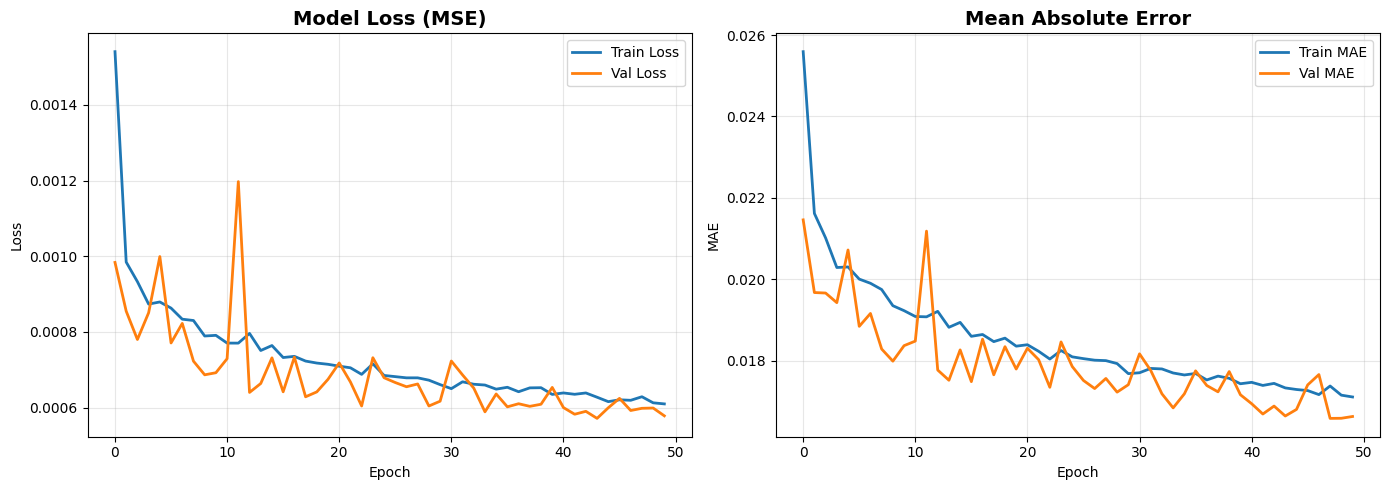

Training history plot saved!
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


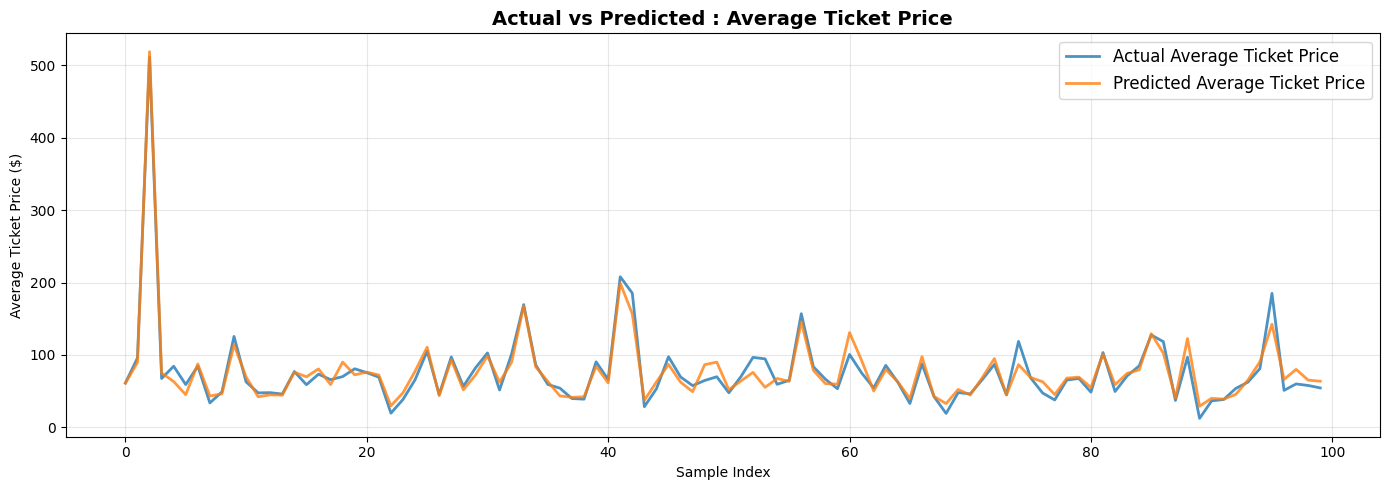

Prediction plot saved!

  PREDICTION FOR : Wicked
  Next week Average Ticket Price : $96.16


In [8]:
# ============================================================
#  CNN + LSTM Model for Broadway Show Revenue Prediction
#  Ready to run in Google Colab
# ============================================================
#
#  GOAL : Predict next week's "Average_ticket" for a Broadway
#         show using the previous N weeks of performance data.
#
#  HOW  : 1D CNN extracts local patterns from the weekly
#         sequence, then an LSTM captures longer term trends.
#
#  UPLOAD broadway.csv to Colab before running, or place it
#  in your Google Drive and adjust the path below.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


# ── Step 1 : Load the Dataset ───────────────────────────────

# If running in Colab, upload the file first:
#   from google.colab import files
#   uploaded = files.upload()

df = pd.read_csv("broadway.csv")

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
df.head()


# ── Step 2 : Understand the Columns ─────────────────────────
#
#  Year              : Week start date (dd-mm-yyyy)
#  Show_name         : Name of the Broadway show
#  Potential_Gross   : Maximum possible gross revenue
#  Difference        : Change in gross from prior week
#  Average_ticket    : Average ticket price that week ← TARGET
#  Seats_Sold        : Total seats sold that week
#  Seats_in_theater  : Total seats available in venue
#  Previews          : Number of preview performances
#  %cap              : Percentage of capacity filled
#  diff_cap          : Change in capacity % from prior week


# ── Step 3 : Select Features and Clean Data ──────────────────

# Features the model will learn from
FEATURES = [
    "Potential_Gross",
    "Seats_Sold",
    "Seats_in_theater",
    "Previews",
    "%cap",
    "diff_cap",
    "Difference",
]

TARGET = "Average_ticket"

# Drop rows where the target is zero (no revenue recorded)
df = df[df[TARGET] > 0].copy()

# Drop rows with missing show names
df = df.dropna(subset=["Show_name"])

print(f"Rows after cleaning : {len(df)}")


# ── Step 4 : Normalize the Data ─────────────────────────────
#
#  Neural networks train better when all values are in
#  a similar range (0 to 1). We use MinMaxScaler for this.

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Scale features
X_scaled = scaler_X.fit_transform(df[FEATURES].values)

# Scale target (reshape to 2D for the scaler)
y_scaled = scaler_y.fit_transform(df[[TARGET]].values)

print(f"Feature matrix shape : {X_scaled.shape}")
print(f"Target vector shape  : {y_scaled.shape}")


# ── Step 5 : Create Sequences (Sliding Window) ──────────────
#
#  The model needs to look at the PAST N weeks to predict
#  the NEXT week. We slide a window across each show's data.
#
#  Example with WINDOW_SIZE = 8 :
#    Input  = weeks 1,2,3,4,5,6,7,8  →  Predict week 9
#    Input  = weeks 2,3,4,5,6,7,8,9  →  Predict week 10
#    ...

WINDOW_SIZE = 13   # Number of past weeks to use

# Encode show names to group sequences per show
le = LabelEncoder()
df["show_id"] = le.fit_transform(df["Show_name"])

def create_sequences(X, y, show_ids, window_size):
    """
    Build sliding window sequences, grouped by show.
    Each sequence contains `window_size` consecutive weeks
    from the SAME show.
    """
    sequences = []
    targets   = []

    unique_shows = np.unique(show_ids)

    for show in unique_shows:
        # Get indices belonging to this show
        idx = np.where(show_ids == show)[0]

        # Skip shows with too few weeks of data
        if len(idx) <= window_size:
            continue

        # Slide the window across this show's timeline
        for i in range(len(idx) - window_size):
            seq_idx    = idx[i : i + window_size]
            target_idx = idx[i + window_size]

            sequences.append(X[seq_idx])
            targets.append(y[target_idx])

    return np.array(sequences), np.array(targets)


X_seq, y_seq = create_sequences(
    X_scaled, y_scaled, df["show_id"].values, WINDOW_SIZE
)

print(f"\nSequences created!")
print(f"  X shape : {X_seq.shape}")
print(f"    → {X_seq.shape[0]} samples")
print(f"    → {X_seq.shape[1]} time steps (weeks)")
print(f"    → {X_seq.shape[2]} features per week")
print(f"  y shape : {y_seq.shape}")


# ── Step 6 : Split into Train and Test Sets ──────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


# ── Step 7 : Build the CNN + LSTM Model ──────────────────────
#
#  Architecture overview :
#
#    Input (13 weeks x 7 features)
#       ↓
#    Conv1D ── extracts short term patterns (e.g. 3 week trends)
#       ↓
#    MaxPooling1D ── reduces sequence length, keeps key signals
#       ↓
#    LSTM ── learns how patterns evolve over time
#       ↓
#    Dense ── final prediction of next week's average ticket price
#

n_timesteps = X_train.shape[1]   # 13
n_features  = X_train.shape[2]   # 7

model = Sequential([

    # --- CNN Block ---
    # 128 filters, each looking at 3 consecutive weeks
    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu",
        input_shape=(n_timesteps, n_features)
    ),

    # Keep the strongest signals
    MaxPooling1D(pool_size=2),

    # Dropout to prevent overfitting (20% of neurons off)
    Dropout(0.2),

    # 64 filters, each looking at 4 consecutive weeks
    Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(n_timesteps, n_features)),
    MaxPooling1D(pool_size=2),

    # --- LSTM Block ---
    # 50 memory units to capture temporal dependencies
    LSTM(50, activation="relu"),

    # --- Output ---
    # Single neuron outputs the predicted average ticket price
    Dense(1),
])

# Compile with Adam optimizer and Mean Squared Error loss
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]     # Mean Absolute Error for monitoring
)

# Print a summary of the model layers
model.summary()


# ── Step 8 : Train the Model ────────────────────────────────

# Stop early if validation loss stops improving for 10 epochs
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("\nTraining the model...\n")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# ── Step 9 : Evaluate the Model ─────────────────────────────

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

# Convert MAE back to original dollar scale
mae_dollars = scaler_y.inverse_transform([[test_mae]])[0][0]

print(f"\n{'='*45}")
print(f"  TEST RESULTS")
print(f"{'='*45}")
print(f"  MSE Loss (scaled)   : {test_loss:.6f}")
print(f"  MAE (scaled)        : {test_mae:.6f}")
print(f"  MAE (dollars)       : ${mae_dollars:,.0f}")
print(f"{'='*45}")


# ── Step 10 : Plot Training History ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Model Loss (MSE)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(history.history["mae"], label="Train MAE", linewidth=2)
axes[1].plot(history.history["val_mae"], label="Val MAE", linewidth=2)
axes[1].set_title("Mean Absolute Error", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training history plot saved!")


# ── Step 11 : Actual vs Predicted Plot ───────────────────────

# Make predictions on test set
y_pred_scaled = model.predict(X_test)

# Convert back to original dollar values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Plot first 100 samples for clarity
n_plot = 100

plt.figure(figsize=(14, 5))
plt.plot(y_true[:n_plot], label="Actual Average Ticket Price", linewidth=2, alpha=0.8)
plt.plot(y_pred[:n_plot], label="Predicted Average Ticket Price", linewidth=2, alpha=0.8)
plt.title("Actual vs Predicted : Average Ticket Price",
          fontsize=14, fontweight="bold")
plt.xlabel("Sample Index")
plt.ylabel("Average Ticket Price ($)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Prediction plot saved!")


# ── Step 12 : Predict for a Specific Show ────────────────────
#
#  Example: predict next week for the most recent 13 weeks
#  of "Wicked" data.

show_name = "Wicked"

if show_name in df["Show_name"].values:
    show_data = df[df["Show_name"] == show_name]
    last_weeks = show_data[FEATURES].tail(WINDOW_SIZE).values

    # Scale and reshape for the model
    last_weeks_scaled = scaler_X.transform(last_weeks)
    last_weeks_input  = last_weeks_scaled.reshape(1, WINDOW_SIZE, len(FEATURES))

    # Predict
    pred_scaled = model.predict(last_weeks_input, verbose=0)
    pred_value  = scaler_y.inverse_transform(pred_scaled)[0][0]

    print(f"\n{'='*45}")
    print(f"  PREDICTION FOR : {show_name}")
    print(f"{'='*45}")
    print(f"  Next week Average Ticket Price : ${pred_value:,.2f}")
    print(f"{'='*45}")
else:
    print(f"'{show_name}' not found in the dataset.")


# ============================================================
#  Model Summary :
#
#  1. Takes 13 weeks of show performance data as input
#  2. CNN layer finds short term patterns (3 week trends)
#  3. LSTM layer captures how those patterns change over time
#  4. Outputs a single prediction for next week's average ticket price
#
#  To improve this model, you can try :
#    → Increase WINDOW_SIZE to 12 or 16
#    → Add more Conv1D or LSTM layers
#    → Use Bidirectional(LSTM(...)) for richer context
#    → Add show name as an embedding feature
#    → Tune hyperparameters with Keras Tuner
# ============================================================